## Environment setup

Installs the metric libraries used later in the notebook and restarts the Python runtime so the packages are available.


In [0]:
# This setup cell prepares the runtime with the static-analysis libraries used below.

# Install the required analysis libraries for code metrics.

%pip install radon==6.0.1 lizard==1.17.10
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Imports and pipeline configuration

Defines dependencies, workspace paths for both pipeline paradigms, and shared chart colors.


In [0]:
# This cell centralizes all constants that are reused across metric calculation and plotting.

# Import dependencies and define the global notebook configuration.

import os
import pandas as pd

from radon.complexity import cc_visit
from radon.metrics import mi_visit
from radon.raw import analyze as raw_analyze

import lizard

# Root folders for both pipeline implementations in the Databricks workspace.
DECLARATIVE_ROOT = "/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations"
IMPERATIVE_ROOT  = "/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative"

PIPELINES = {
    "declarative": DECLARATIVE_ROOT,
    "imperative": IMPERATIVE_ROOT,
}

declarative_color = "#0F2DB3"
imperative_color = "#0072EF"

## File metadata helpers

Provides small helper functions to derive the medallion layer, job name, and data quality flag from each file path.


In [0]:
# These helpers convert file naming conventions into analysis dimensions used throughout the notebook.

# Helper functions for deriving pipeline metadata from file paths.

def detect_layer_from_filename(path: str) -> str:
    base = os.path.basename(path)
    if base.startswith("01_"):
        return "bronze"
    elif base.startswith("02_"):
        return "silver"
    elif base.startswith("03_"):
        return "gold"
    else:
        return "unknown"


def is_data_quality(path: str) -> bool:
    return "data_quality" in path.replace("\\", "/")


def detect_job_name(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    return name

## Radon file analysis helper

Wraps Radon calls to calculate SLOC, cyclomatic complexity, and maintainability metrics for a single Python file.


In [0]:
# This function normalizes Radon's raw outputs into a compact dictionary of file-level metrics.

# Helper function for analyzing one Python file with Radon.

def analyze_python_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        code = f.read()

    # Raw metrics (inkl. SLOC)
    raw = raw_analyze(code)
    sloc = raw.sloc

    # Cyclomatic Complexity
    cc_results = cc_visit(code)
    if cc_results:
        cc_scores = [item.complexity for item in cc_results]
        avg_cc = sum(cc_scores) / len(cc_scores)
        max_cc = max(cc_scores)
        cc_count = len(cc_scores)
    else:
        avg_cc = 0.0
        max_cc = 0.0
        cc_count = 0

    # Maintainability Index
    mi_results = mi_visit(code, multi=True)

    # mi_results kann ein Float oder eine Sequenz sein
    mi_scores = []
    if isinstance(mi_results, (int, float)):
        mi_scores = [float(mi_results)]
    elif mi_results:
        # Radon gibt hier eine Sequenz von Objekten mit Attribut .mi zurück
        # oder direkt eine Sequenz von Floats, je nach Version
        first = mi_results[0]
        if hasattr(first, "mi"):
            mi_scores = [r.mi for r in mi_results]
        else:
            mi_scores = [float(r) for r in mi_results]

    if mi_scores:
        avg_mi = sum(mi_scores) / len(mi_scores)
        min_mi = min(mi_scores)
        mi_count = len(mi_scores)
    else:
        avg_mi = 100.0
        min_mi = 100.0
        mi_count = 0

    return {
        "sloc": sloc,
        "avg_cc": avg_cc,
        "max_cc": max_cc,
        "cc_entities": cc_count,
        "avg_mi": avg_mi,
        "min_mi": min_mi,
        "mi_entities": mi_count,
    }

## Discover pipeline source files

Scans both implementations, records metadata for every Python file, and separates business transformations from data quality jobs.


In [0]:
# This cell builds the file inventory that acts as the input dataset for all later code metrics.

# Collect all Python files from both pipelines and enrich them with metadata.

records = []

for pipeline_type, root in PIPELINES.items():
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if not fname.endswith(".py"):
                continue

            full_path = os.path.join(dirpath, fname)

            records.append({
                "pipeline": pipeline_type,
                "file_path": full_path,
                "layer": detect_layer_from_filename(full_path),
                "job": detect_job_name(full_path),
                "is_data_quality": is_data_quality(full_path),
            })

df_files = pd.DataFrame(records)

print("All discovered .py files:")
display(df_files)

print("Business transformation jobs only, excluding data_quality:")
df_main_jobs = df_files[~df_files["is_data_quality"]].reset_index(drop=True)
display(df_main_jobs)

Alle gefundenen .py-Dateien:


pipeline,file_path,layer,job,is_data_quality
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/03_dp_gold.py,gold,03_dp_gold,false
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/02_dp_silver.py,silver,02_dp_silver,false
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/01_dp_bronze.py,bronze,01_dp_bronze,false
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/00_dq_bronze_rule_catalog.py,unknown,00_dq_bronze_rule_catalog,true
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/03_dp_gold_quality.py,gold,03_dp_gold_quality,true
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/02_dp_silver_quality.py,silver,02_dp_silver_quality,true
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/01_dp_bronze_quality.py,bronze,01_dp_bronze_quality,true
imperative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/03_ip_gold_models.py,gold,03_ip_gold_models,false
imperative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/01_ip_bronze_tables.py,bronze,01_ip_bronze_tables,false
imperative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/02_ip_silver_tables.py,silver,02_ip_silver_tables,false


Nur fachliche Transformationsjobs (ohne data_quality):


pipeline,file_path,layer,job,is_data_quality
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/03_dp_gold.py,gold,03_dp_gold,false
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/02_dp_silver.py,silver,02_dp_silver,false
declarative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/01_dp_bronze.py,bronze,01_dp_bronze,false
imperative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/03_ip_gold_models.py,gold,03_ip_gold_models,false
imperative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/01_ip_bronze_tables.py,bronze,01_ip_bronze_tables,false
imperative,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/02_ip_silver_tables.py,silver,02_ip_silver_tables,false


## Calculate file-level code metrics

Runs the Radon helper for each discovered file and builds the base metrics table.


In [0]:
# This loop applies the Radon helper to every file and keeps the original file metadata attached.

# Calculate Radon metrics for every discovered Python file.

metrics_records = []

for _, row in df_files.iterrows():
    path = row["file_path"]
    try:
        metrics = analyze_python_file(path)
    except Exception as e:
        print(f"Error while analyzing {path}: {e}")
        continue

    record = {
        "pipeline": row["pipeline"],
        "layer": row["layer"],
        "job": row["job"],
        "file_path": row["file_path"],
        "is_data_quality": row["is_data_quality"],
    }
    record.update(metrics)
    metrics_records.append(record)

df_metrics_file = pd.DataFrame(metrics_records)

print("File-level Radon metrics:")
display(df_metrics_file)

Radon-Metriken auf Datei-Ebene:


pipeline,layer,job,file_path,is_data_quality,sloc,avg_cc,max_cc,cc_entities,avg_mi,min_mi,mi_entities
declarative,gold,03_dp_gold,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/03_dp_gold.py,false,220,1.0,1,6,48.40829875646968,48.40829875646968,1
declarative,silver,02_dp_silver,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/02_dp_silver.py,false,235,1.1428571428571428,2,7,44.45862500172031,44.45862500172031,1
declarative,bronze,01_dp_bronze,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/01_dp_bronze.py,false,23,1.0,1,6,100.0,100.0,1
declarative,unknown,00_dq_bronze_rule_catalog,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/00_dq_bronze_rule_catalog.py,true,62,1.0,1,2,100.0,100.0,1
declarative,gold,03_dp_gold_quality,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/03_dp_gold_quality.py,true,97,1.2,2,5,54.98819210873613,54.98819210873613,1
declarative,silver,02_dp_silver_quality,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/02_dp_silver_quality.py,true,179,1.3333333333333333,3,6,50.68257229825169,50.68257229825169,1
declarative,bronze,01_dp_bronze_quality,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/01_dp_bronze_quality.py,true,85,1.8333333333333333,3,6,57.757045644229976,57.757045644229976,1
imperative,gold,03_ip_gold_models,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/03_ip_gold_models.py,false,262,1.0909090909090908,2,11,55.0242109127497,55.0242109127497,1
imperative,bronze,01_ip_bronze_tables,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/01_ip_bronze_tables.py,false,37,1.2,2,5,89.16193086176848,89.16193086176848,1
imperative,silver,02_ip_silver_tables,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/02_ip_silver_tables.py,false,248,1.0909090909090908,2,11,47.56514948157136,47.56514948157136,1


## Detect duplicate code blocks

Uses Lizard to identify repeated code blocks and aggregates duplicate counts per job.


In [0]:
# This optional step enriches the metric dataset with duplicate-code information from Lizard.

# COMMAND ----------
# Optional: analyze duplicated code blocks with Lizard and handle empty results safely.

dup_records = []

for pipeline_type, root in PIPELINES.items():
    print(f"Lizard-Analyse für Pipeline {pipeline_type}: {root}")
    result = lizard.analyze(root)

    duplicate_groups = getattr(result, "crossfile_duplication", None) \
        or getattr(result, "cross_file_duplicate", None) \
        or []

    for dup_group in duplicate_groups:
        files = getattr(dup_group, "files", [])
        for fi in files:
            file_path = fi.filename
            start_line = fi.start_line
            end_line = fi.end_line

            match = df_files[df_files["file_path"] == file_path]
            if match.empty:
                continue

            meta = match.iloc[0]

            dup_records.append({
                "pipeline": pipeline_type,
                "file_path": file_path,
                "layer": meta["layer"],
                "job": meta["job"],
                "is_data_quality": meta["is_data_quality"],
                "dup_block_id": id(dup_group),
                "start_line": start_line,
                "end_line": end_line,
            })

# Build the duplicate-block DataFrame only from detected records.
if dup_records:
    df_dups = pd.DataFrame(dup_records)
    print("Detected duplicate blocks, raw Pandas DataFrame:")
    display(df_dups)
else:
    # Print an informational message instead of displaying an empty DataFrame.
    df_dups = pd.DataFrame(
        columns=[
            "pipeline",
            "file_path",
            "layer",
            "job",
            "is_data_quality",
            "dup_block_id",
            "start_line",
            "end_line",
        ]
    )
    print("No duplicate blocks found; df_dups is empty.")

# Aggregate duplicate blocks only when Lizard returned entries.
if not df_dups.empty:
    df_dup_counts = (
        df_dups.groupby(["pipeline", "layer", "job", "is_data_quality"], as_index=False)["dup_block_id"]
        .nunique()
        .rename(columns={"dup_block_id": "duplicated_blocks"})
    )
    print("Number of duplicated blocks per job, Pandas DataFrame:")
    display(df_dup_counts)
else:
    df_dup_counts = pd.DataFrame(
        columns=["pipeline", "layer", "job", "is_data_quality", "duplicated_blocks"]
    )
    print("No duplicates found; df_dup_counts is empty.")

Lizard-Analyse für Pipeline declarative: /Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations
Lizard-Analyse für Pipeline imperative: /Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative
Keine Duplikat-Blöcke gefunden – df_dups ist leer.
Keine Duplikate – df_dup_counts ist leer.


## Combine code metrics and duplication metrics

Merges Radon metrics with duplicate-code counts and creates the main analysis table.


In [0]:
# This cell creates the combined analysis table used for reporting and visualization.

# Combine Radon code metrics and duplicate-code counts into one DataFrame.
# Ensure that the file-level Radon metrics DataFrame exists.
if "df_metrics_file" not in globals():
    # Raise a clear error if the required metrics cell has not been executed.
    raise RuntimeError(
        "df_metrics_file is not defined. "
        "Please run the cell that calculates file-level Radon metrics first."
    )

# Create an empty duplicate-count DataFrame if the Lizard cell was skipped or failed.
if "df_dup_counts" not in globals():
    df_dup_counts = pd.DataFrame(
        columns=["pipeline", "layer", "job", "is_data_quality", "duplicated_blocks"]
    )

# Merge Radon metrics with duplicate-code counts.
df_all = df_metrics_file.merge(
    df_dup_counts,
    on=["pipeline", "layer", "job", "is_data_quality"],
    how="left"
)

# Treat missing duplicate-code values as zero.
df_all["duplicated_blocks"] = df_all["duplicated_blocks"].fillna(0).astype(int)

print("All metrics, including duplicates, at job level:")
display(df_all)

print("Business transformation jobs only, excluding data_quality, with all metrics:")
df_all_main = df_all[~df_all["is_data_quality"]]
display(df_all_main)

/home/spark-b218a20d-0f8f-4aac-92c5-97/.ipykernel/3187/command-7421263666608526-653847669:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["duplicated_blocks"] = df_all["duplicated_blocks"].fillna(0).astype(int)


Alle Metriken (inkl. Duplikate) auf Job-Ebene:


pipeline,layer,job,file_path,is_data_quality,sloc,avg_cc,max_cc,cc_entities,avg_mi,min_mi,mi_entities,duplicated_blocks
declarative,gold,03_dp_gold,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/03_dp_gold.py,false,220,1.0,1,6,48.40829875646968,48.40829875646968,1,0
declarative,silver,02_dp_silver,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/02_dp_silver.py,false,235,1.1428571428571428,2,7,44.45862500172031,44.45862500172031,1,0
declarative,bronze,01_dp_bronze,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/01_dp_bronze.py,false,23,1.0,1,6,100.0,100.0,1,0
declarative,unknown,00_dq_bronze_rule_catalog,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/00_dq_bronze_rule_catalog.py,true,62,1.0,1,2,100.0,100.0,1,0
declarative,gold,03_dp_gold_quality,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/03_dp_gold_quality.py,true,97,1.2,2,5,54.98819210873613,54.98819210873613,1,0
declarative,silver,02_dp_silver_quality,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/02_dp_silver_quality.py,true,179,1.3333333333333333,3,6,50.68257229825169,50.68257229825169,1,0
declarative,bronze,01_dp_bronze_quality,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/data_quality/01_dp_bronze_quality.py,true,85,1.8333333333333333,3,6,57.757045644229976,57.757045644229976,1,0
imperative,gold,03_ip_gold_models,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/03_ip_gold_models.py,false,262,1.0909090909090908,2,11,55.0242109127497,55.0242109127497,1,0
imperative,bronze,01_ip_bronze_tables,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/01_ip_bronze_tables.py,false,37,1.2,2,5,89.16193086176848,89.16193086176848,1,0
imperative,silver,02_ip_silver_tables,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/02_ip_silver_tables.py,false,248,1.0909090909090908,2,11,47.56514948157136,47.56514948157136,1,0


Nur fachliche Transformationsjobs (ohne data_quality), alle Metriken:


pipeline,layer,job,file_path,is_data_quality,sloc,avg_cc,max_cc,cc_entities,avg_mi,min_mi,mi_entities,duplicated_blocks
declarative,gold,03_dp_gold,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/03_dp_gold.py,false,220,1.0,1,6,48.40829875646968,48.40829875646968,1,0
declarative,silver,02_dp_silver,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/02_dp_silver.py,false,235,1.1428571428571428,2,7,44.45862500172031,44.45862500172031,1,0
declarative,bronze,01_dp_bronze,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/declarative/transformations/01_dp_bronze.py,false,23,1.0,1,6,100.0,100.0,1,0
imperative,gold,03_ip_gold_models,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/03_ip_gold_models.py,false,262,1.0909090909090908,2,11,55.0242109127497,55.0242109127497,1,0
imperative,bronze,01_ip_bronze_tables,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/01_ip_bronze_tables.py,false,37,1.2,2,5,89.16193086176848,89.16193086176848,1,0
imperative,silver,02_ip_silver_tables,/Workspace/Users/klementf.wwi23@student.dhbw-heidenheim.de/imperative/02_ip_silver_tables.py,false,248,1.0909090909090908,2,11,47.56514948157136,47.56514948157136,1,0


## Aggregate metrics by pipeline and layer

Summarizes business transformation metrics by paradigm and medallion layer for later comparison.


In [0]:
# This aggregation reduces job-level metrics to layer-level averages for the main thesis comparison.

# Aggregate metrics by pipeline and medallion layer for evaluation.

df_summary = (
    df_all_main
    .groupby(["pipeline", "layer"], as_index=False)
    .agg({
        "sloc": "mean",
        "avg_cc": "mean",
        "avg_mi": "mean",
        "duplicated_blocks": "mean",
    })
    .rename(columns={
        "sloc": "avg_sloc_per_job",
        "avg_cc": "avg_cc_per_job",
        "avg_mi": "avg_mi_per_job",
        "duplicated_blocks": "avg_dup_blocks_per_job",
    })
    .sort_values(["pipeline", "layer"])
)

print("Summary by pipeline and layer, business jobs only:")
display(df_summary)

Zusammenfassung pro Pipeline und Layer (nur fachliche Jobs):


pipeline,layer,avg_sloc_per_job,avg_cc_per_job,avg_mi_per_job,avg_dup_blocks_per_job
declarative,bronze,23.0,1.0,100.0,0.0
declarative,gold,220.0,1.0,48.40829875646968,0.0
declarative,silver,235.0,1.1428571428571428,44.45862500172031,0.0
imperative,bronze,37.0,1.2,89.16193086176848,0.0
imperative,gold,262.0,1.0909090909090908,55.0242109127497,0.0
imperative,silver,248.0,1.0909090909090908,47.56514948157136,0.0


## Create pipeline-level summaries

Builds separate summaries for all jobs, business jobs only, and data quality jobs only.


In [0]:
# These summaries compare the two paradigms at different scopes: all jobs, business jobs, and DQ jobs.

import pandas as pd

if "df_all" not in globals():
    raise RuntimeError(
        "df_all is not defined. "
        "Please run the combination cell for Radon metrics and duplicate counts first."
    )

# 1) Alle Jobs (inkl. data_quality)
df_summary_all = (
    df_all
    .groupby(["pipeline"], as_index=False)
    .agg({
        "sloc": "mean",
        "avg_cc": "mean",
        "avg_mi": "mean",
        "duplicated_blocks": "mean",
    })
    .rename(columns={
        "sloc": "avg_sloc_per_job",
        "avg_cc": "avg_cc_per_job",
        "avg_mi": "avg_mi_per_job",
        "duplicated_blocks": "avg_dup_blocks_per_job",
    })
)

# Round the aggregated values to two decimal places for reporting.
df_summary_all = df_summary_all.round(2)

print("Pipeline summary for all jobs, including data_quality:")
display(df_summary_all)

# 2) Nur fachliche Jobs (ohne data_quality)
df_all_main = df_all[~df_all["is_data_quality"]]

df_summary_main = (
    df_all_main
    .groupby(["pipeline"], as_index=False)
    .agg({
        "sloc": "mean",
        "avg_cc": "mean",
        "avg_mi": "mean",
        "duplicated_blocks": "mean",
    })
    .rename(columns={
        "sloc": "avg_sloc_per_job",
        "avg_cc": "avg_cc_per_job",
        "avg_mi": "avg_mi_per_job",
        "duplicated_blocks": "avg_dup_blocks_per_job",
    })
)

df_summary_main = df_summary_main.round(2)

print("Pipeline summary for business jobs only, excluding data_quality:")
display(df_summary_main)

# 3) Nur data_quality-Jobs
df_all_dq = df_all[df_all["is_data_quality"]]

if not df_all_dq.empty:
    df_summary_dq = (
        df_all_dq
        .groupby(["pipeline"], as_index=False)
        .agg({
            "sloc": "mean",
            "avg_cc": "mean",
            "avg_mi": "mean",
            "duplicated_blocks": "mean",
        })
        .rename(columns={
            "sloc": "avg_sloc_per_job",
            "avg_cc": "avg_cc_per_job",
            "avg_mi": "avg_mi_per_job",
            "duplicated_blocks": "avg_dup_blocks_per_job",
        })
    )

    df_summary_dq = df_summary_dq.round(2)

    print("Pipeline summary for data_quality jobs only:")
    display(df_summary_dq)
else:
    print("No data_quality jobs were found; no data_quality summary is created.")

Summary pro Pipeline (ALLE Jobs, inkl. data_quality):


pipeline,avg_sloc_per_job,avg_cc_per_job,avg_mi_per_job,avg_dup_blocks_per_job
declarative,128.71,1.22,65.18,0.0
imperative,186.67,1.23,61.74,0.0


Summary pro Pipeline (nur fachliche Jobs, OHNE data_quality):


pipeline,avg_sloc_per_job,avg_cc_per_job,avg_mi_per_job,avg_dup_blocks_per_job
declarative,159.33,1.05,64.29,0.0
imperative,182.33,1.13,63.92,0.0


Summary pro Pipeline (NUR data_quality-Jobs):


pipeline,avg_sloc_per_job,avg_cc_per_job,avg_mi_per_job,avg_dup_blocks_per_job
declarative,105.75,1.34,65.86,0.0
imperative,191.0,1.33,59.56,0.0


## Visualize development code metrics

Generates comparison charts for SLOC, cyclomatic complexity, and maintainability index.


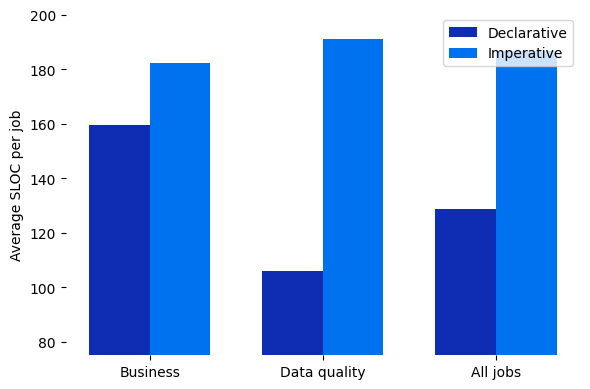

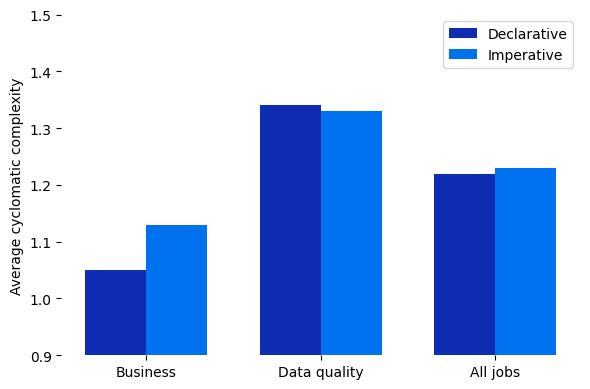

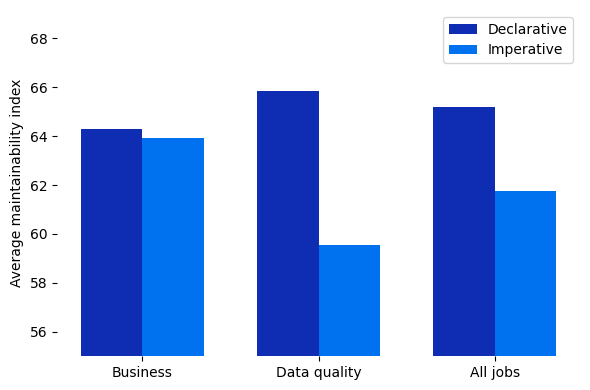

In [0]:
# This plotting cell turns the summary tables into exportable figures for the written thesis.

# Create comparison figures for the development code metrics.


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

required_dfs = ["df_summary_main", "df_summary_dq", "df_summary_all"]
for name in required_dfs:
    if name not in globals():
        raise RuntimeError(
            f"{name} is not defined. "
            "Please run the cells that create the summary DataFrames first."
        )

def extract_segment_values(kpi_col: str):
    main_dec = df_summary_main.loc[df_summary_main["pipeline"] == "declarative", kpi_col].iloc[0]
    main_imp = df_summary_main.loc[df_summary_main["pipeline"] == "imperative", kpi_col].iloc[0]

    dq_dec = df_summary_dq.loc[df_summary_dq["pipeline"] == "declarative", kpi_col].iloc[0]
    dq_imp = df_summary_dq.loc[df_summary_dq["pipeline"] == "imperative", kpi_col].iloc[0]

    all_dec = df_summary_all.loc[df_summary_all["pipeline"] == "declarative", kpi_col].iloc[0]
    all_imp = df_summary_all.loc[df_summary_all["pipeline"] == "imperative", kpi_col].iloc[0]

    return (
        [main_dec, dq_dec, all_dec],
        [main_imp, dq_imp, all_imp]
    )

segments = ["Business", "Data quality", "All jobs"]
x = np.arange(len(segments))
width = 0.35

# --- Figure 1: Average SLOC per job ---

sloc_dec, sloc_imp = extract_segment_values("avg_sloc_per_job")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, sloc_dec, width, label="Declarative", color=declarative_color)
ax.bar(x + width/2, sloc_imp, width, label="Imperative", color=imperative_color)
ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.set_ylabel("Average SLOC per job")
ax.set_ylim(75, None)
ax.legend()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("figure_sloc.png", dpi=300)
plt.show()

# --- Figure 2: Average cyclomatic complexity ---

cc_dec, cc_imp = extract_segment_values("avg_cc_per_job")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, cc_dec, width, label="Declarative", color=declarative_color)
ax.bar(x + width/2, cc_imp, width, label="Imperative", color=imperative_color)
ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.set_ylabel("Average cyclomatic complexity")
ax.set_ylim(0.9, 1.5)
ax.legend()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("figure_cc.png", dpi=300)
plt.show()

# --- Figure 3: Average maintainability index ---

mi_dec, mi_imp = extract_segment_values("avg_mi_per_job")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, mi_dec, width, label="Declarative", color=declarative_color)
ax.bar(x + width/2, mi_imp, width, label="Imperative", color=imperative_color)
ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.set_ylabel("Average maintainability index")
ax.set_ylim(55, None)
ax.legend()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("figure_mi.png", dpi=300)
plt.show()
